In [1]:
!pip install torchvision

In [2]:
import torch
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [27]:
# Image load => transform => dataset of all imgs
class ImageProcessor(Dataset):
    def __init__(self, root_dir_path, transformations):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        # list of path for all images
        self.all_imgs_path = [os.path.join(root_dir_path, img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_imgs_path)

    def __getitem__(self, idx):
        img_path = self.all_imgs_path[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)
        return img
        
        
    

In [28]:
root_dir_path = "./img_align_celeba"
transformations = transforms.Compose([
    transforms.CenterCrop(178), # 178*218 => 178*178
    transforms.Resize(64), # 64*64
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [-1, 1]
])

In [29]:
dataset = ImageProcessor(root_dir_path, transformations)
print(f"loaded {len(dataset)} images")

loaded 202599 images


In [30]:
dataloader = DataLoader(dataset, batch_size = 128, shuffle = True)
print(type(dataloader))

<class 'torch.utils.data.dataloader.DataLoader'>


# Generator Network

In [31]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [32]:
class Generator(nn.Module): # Generator gets fake data which we represent here by z which is basically the random vecotrs of noise(fake imgs data)
    def __init__(self, z_dim = 100, img_channels = 3): # 3 is for RGB, z is noise the image random vectors
        super(Generator, self).__init__()

        # Fully connected layer

        self.model = nn.Sequential(
            nn.Linear(z_dim, 256), # 100 => 256
            nn.ReLU(),


            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 64*64*img_channels),
            nn.Tanh() # [-1, 1] normalize pixel in this range

        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64)
        return img


        # fake image = 64 * 64 * 3 * batchSize so thats's 4D

# Discriminator Network

In [50]:
class Discriminator(nn.Module): 
    def __init__(self, img_channels = 3, img_size = 64): # 3 is for RGB,
        super(Discriminator, self).__init__()
        input_dim = img_channels * img_size * img_size
        # Fully connected layer

        self.model = nn.Sequential(

            nn.Flatten(), # 4D Tensors => 1D
                
            nn.Linear(input_dim, 1024), # 100 => 256
            nn.LeakyReLU(),


            nn.Linear(1024, 512),
            nn.LeakyReLU(),

            nn.Linear(512, 256),
            nn.LeakyReLU(),

            nn.Linear(256, 1),
            nn.Sigmoid() # Probability of being fake or real

        )

    def forward(self, z):
        return self.model(z)


In [51]:
GAN_loss = nn.BCELoss() # Binary Cross Entropy loss

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr = 0.0002, betas = (0.5, 0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(), lr = 0.0002, betas = (0.5, 0.999))



# Device

In [52]:
import torch
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("My device: ", device)

My device:  mps


In [53]:
generator = generator.to(device)
discriminator = discriminator.to(device)

# Training the GAN

In [57]:
def trian(generator, discriminator, dataloader, epochs = 10):

    for epoch in range(epochs):
        for i, img in enumerate(dataloader):
            real_imgs = img.to(device)
            batch_size =  real_imgs.size(0)

            # create real img labels and fake image labels
            real_labels = torch.ones(batch_size, 1).to(device) # [1,1,1,.....]
            fake_labels = torch.zeros(batch_size, 1).to(device) # [0,0,0,......]

            # Trian the disscriminator
            d_optimizer.zero_grad()

            noise = torch.randn(batch_size, 100).to(device)
            fake_imgs = generator(noise)

            real_loss = GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # Train the generator
            g_optimizer.zero_grad()

            g_loss = GAN_loss(discriminator(fake_imgs),  real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(f"for epoch in {epoch + 1}/{epochs}... batch: {i + 1}... G-loss: {g_loss.item()} & D-loss: {d_loss.item()}")
        # save generated img for each epoch
        save_generated_images(generator, epoch, device)
            

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch + 1}")
    plt.axis("off")
    plt.show()

for epoch in 1/10... batch: 1... G-loss: 3.766336441040039 & D-loss: 0.2028336226940155
for epoch in 1/10... batch: 51... G-loss: 2.551413059234619 & D-loss: 0.17704549431800842
for epoch in 1/10... batch: 101... G-loss: 3.2545294761657715 & D-loss: 0.2106834352016449
for epoch in 1/10... batch: 151... G-loss: 4.331635475158691 & D-loss: 0.15006347000598907
for epoch in 1/10... batch: 201... G-loss: 3.2788686752319336 & D-loss: 0.11983753740787506
for epoch in 1/10... batch: 251... G-loss: 2.1900880336761475 & D-loss: 0.20004211366176605
for epoch in 1/10... batch: 301... G-loss: 4.224980354309082 & D-loss: 0.37901830673217773
for epoch in 1/10... batch: 351... G-loss: 4.8095011711120605 & D-loss: 0.18857337534427643
for epoch in 1/10... batch: 401... G-loss: 2.427898406982422 & D-loss: 0.18131211400032043
for epoch in 1/10... batch: 451... G-loss: 2.425929069519043 & D-loss: 0.20191839337348938
for epoch in 1/10... batch: 501... G-loss: 3.910773277282715 & D-loss: 0.12036425620317459


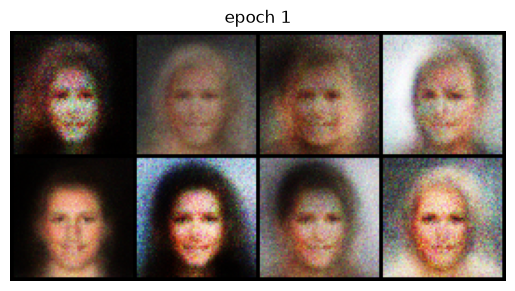

for epoch in 2/10... batch: 1... G-loss: 2.1746537685394287 & D-loss: 0.3358347415924072
for epoch in 2/10... batch: 51... G-loss: 3.410630941390991 & D-loss: 0.2547627091407776
for epoch in 2/10... batch: 101... G-loss: 2.760377883911133 & D-loss: 0.34488290548324585
for epoch in 2/10... batch: 151... G-loss: 2.2206807136535645 & D-loss: 0.24078825116157532
for epoch in 2/10... batch: 201... G-loss: 2.205763101577759 & D-loss: 0.2647293508052826
for epoch in 2/10... batch: 251... G-loss: 4.073925971984863 & D-loss: 0.4795491397380829
for epoch in 2/10... batch: 301... G-loss: 2.589548349380493 & D-loss: 0.27132123708724976
for epoch in 2/10... batch: 351... G-loss: 4.397345066070557 & D-loss: 0.26842057704925537
for epoch in 2/10... batch: 401... G-loss: 2.2685680389404297 & D-loss: 0.32685285806655884
for epoch in 2/10... batch: 451... G-loss: 2.288109302520752 & D-loss: 0.31610625982284546
for epoch in 2/10... batch: 501... G-loss: 3.7501955032348633 & D-loss: 0.4211467504501343
for

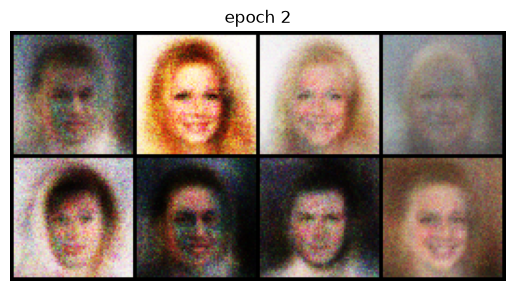

for epoch in 3/10... batch: 1... G-loss: 2.4446165561676025 & D-loss: 0.39354702830314636
for epoch in 3/10... batch: 51... G-loss: 3.1209850311279297 & D-loss: 0.3512890934944153
for epoch in 3/10... batch: 101... G-loss: 2.2691593170166016 & D-loss: 0.3492165505886078
for epoch in 3/10... batch: 151... G-loss: 2.445246458053589 & D-loss: 0.4616927206516266
for epoch in 3/10... batch: 201... G-loss: 2.2957305908203125 & D-loss: 0.32625091075897217
for epoch in 3/10... batch: 251... G-loss: 2.5027518272399902 & D-loss: 0.36271125078201294
for epoch in 3/10... batch: 301... G-loss: 2.1446938514709473 & D-loss: 0.3376519978046417
for epoch in 3/10... batch: 351... G-loss: 1.7671010494232178 & D-loss: 0.4145507216453552
for epoch in 3/10... batch: 401... G-loss: 2.6280345916748047 & D-loss: 0.39391881227493286
for epoch in 3/10... batch: 451... G-loss: 2.199843168258667 & D-loss: 0.35212934017181396
for epoch in 3/10... batch: 501... G-loss: 1.9291189908981323 & D-loss: 0.3269103467464447

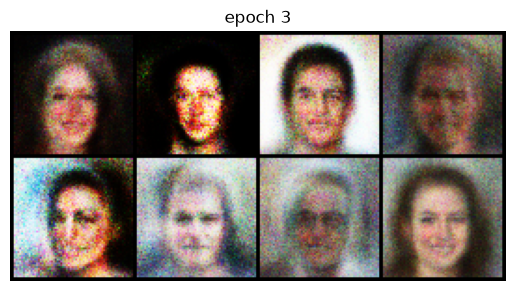

for epoch in 4/10... batch: 1... G-loss: 2.01422119140625 & D-loss: 0.4483461380004883
for epoch in 4/10... batch: 51... G-loss: 2.095773220062256 & D-loss: 0.4372057616710663
for epoch in 4/10... batch: 101... G-loss: 1.857194185256958 & D-loss: 0.36316508054733276
for epoch in 4/10... batch: 151... G-loss: 2.245421886444092 & D-loss: 0.3517300486564636
for epoch in 4/10... batch: 201... G-loss: 2.1006088256835938 & D-loss: 0.400118887424469
for epoch in 4/10... batch: 251... G-loss: 1.9532945156097412 & D-loss: 0.4216281473636627
for epoch in 4/10... batch: 301... G-loss: 2.5561609268188477 & D-loss: 0.38029539585113525
for epoch in 4/10... batch: 351... G-loss: 2.4075400829315186 & D-loss: 0.34424179792404175
for epoch in 4/10... batch: 401... G-loss: 2.27225399017334 & D-loss: 0.2931976914405823
for epoch in 4/10... batch: 451... G-loss: 1.8822327852249146 & D-loss: 0.3863934278488159
for epoch in 4/10... batch: 501... G-loss: 2.430363655090332 & D-loss: 0.3727116584777832
for epoc

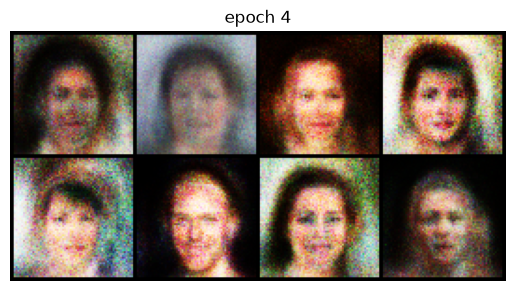

for epoch in 5/10... batch: 1... G-loss: 2.0136494636535645 & D-loss: 0.392133891582489
for epoch in 5/10... batch: 51... G-loss: 2.2226743698120117 & D-loss: 0.38128602504730225
for epoch in 5/10... batch: 101... G-loss: 2.713846206665039 & D-loss: 0.356708288192749
for epoch in 5/10... batch: 151... G-loss: 2.135772466659546 & D-loss: 0.37763136625289917
for epoch in 5/10... batch: 201... G-loss: 2.220165252685547 & D-loss: 0.45967867970466614
for epoch in 5/10... batch: 251... G-loss: 2.1778688430786133 & D-loss: 0.332913339138031
for epoch in 5/10... batch: 301... G-loss: 2.1896934509277344 & D-loss: 0.43934541940689087
for epoch in 5/10... batch: 351... G-loss: 2.0315279960632324 & D-loss: 0.40779078006744385
for epoch in 5/10... batch: 401... G-loss: 2.4246644973754883 & D-loss: 0.415143758058548
for epoch in 5/10... batch: 451... G-loss: 2.060204267501831 & D-loss: 0.4778174161911011
for epoch in 5/10... batch: 501... G-loss: 2.051938533782959 & D-loss: 0.39184731245040894
for e

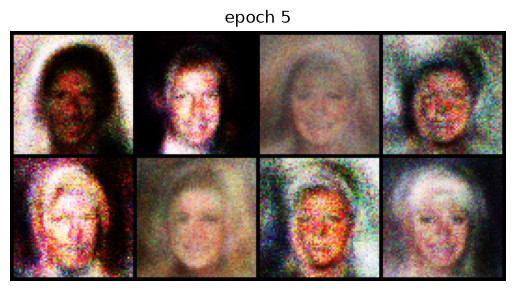

for epoch in 6/10... batch: 1... G-loss: 1.7336485385894775 & D-loss: 0.45941564440727234
for epoch in 6/10... batch: 51... G-loss: 1.9098231792449951 & D-loss: 0.4726840853691101
for epoch in 6/10... batch: 101... G-loss: 1.7413461208343506 & D-loss: 0.42183130979537964
for epoch in 6/10... batch: 151... G-loss: 1.6777937412261963 & D-loss: 0.40524178743362427
for epoch in 6/10... batch: 201... G-loss: 1.8664884567260742 & D-loss: 0.49780720472335815
for epoch in 6/10... batch: 251... G-loss: 1.6479651927947998 & D-loss: 0.43651625514030457
for epoch in 6/10... batch: 301... G-loss: 1.850193977355957 & D-loss: 0.4951794147491455
for epoch in 6/10... batch: 351... G-loss: 1.7579933404922485 & D-loss: 0.3875371813774109
for epoch in 6/10... batch: 401... G-loss: 2.066751480102539 & D-loss: 0.43697917461395264
for epoch in 6/10... batch: 451... G-loss: 1.9230937957763672 & D-loss: 0.4046492576599121
for epoch in 6/10... batch: 501... G-loss: 2.0334718227386475 & D-loss: 0.503058612346649

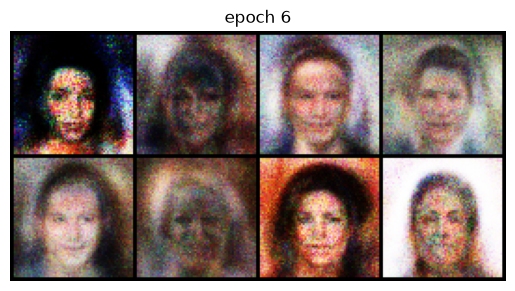

for epoch in 7/10... batch: 1... G-loss: 1.779266357421875 & D-loss: 0.41226476430892944
for epoch in 7/10... batch: 51... G-loss: 1.6118583679199219 & D-loss: 0.4346223473548889
for epoch in 7/10... batch: 101... G-loss: 1.6823965311050415 & D-loss: 0.4790499210357666
for epoch in 7/10... batch: 151... G-loss: 1.9414236545562744 & D-loss: 0.4792364835739136
for epoch in 7/10... batch: 201... G-loss: 1.6565148830413818 & D-loss: 0.4034493863582611
for epoch in 7/10... batch: 251... G-loss: 1.832518458366394 & D-loss: 0.4455345869064331
for epoch in 7/10... batch: 301... G-loss: 1.7650153636932373 & D-loss: 0.41588568687438965
for epoch in 7/10... batch: 351... G-loss: 1.8411626815795898 & D-loss: 0.47119152545928955
for epoch in 7/10... batch: 401... G-loss: 1.7205851078033447 & D-loss: 0.4903501570224762
for epoch in 7/10... batch: 451... G-loss: 1.7652568817138672 & D-loss: 0.4733912944793701
for epoch in 7/10... batch: 501... G-loss: 1.8385640382766724 & D-loss: 0.4672844409942627
f

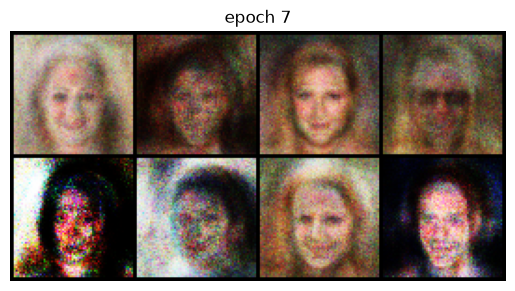

for epoch in 8/10... batch: 1... G-loss: 1.6224825382232666 & D-loss: 0.48038166761398315
for epoch in 8/10... batch: 51... G-loss: 1.7251659631729126 & D-loss: 0.4582972824573517
for epoch in 8/10... batch: 101... G-loss: 1.7348732948303223 & D-loss: 0.49220213294029236
for epoch in 8/10... batch: 151... G-loss: 1.6041500568389893 & D-loss: 0.5342069864273071
for epoch in 8/10... batch: 201... G-loss: 1.7170343399047852 & D-loss: 0.42805856466293335
for epoch in 8/10... batch: 251... G-loss: 1.7804834842681885 & D-loss: 0.46272650361061096
for epoch in 8/10... batch: 301... G-loss: 1.695927381515503 & D-loss: 0.4857805669307709
for epoch in 8/10... batch: 351... G-loss: 1.7408440113067627 & D-loss: 0.48046112060546875
for epoch in 8/10... batch: 401... G-loss: 1.6119916439056396 & D-loss: 0.4872030019760132
for epoch in 8/10... batch: 451... G-loss: 1.8918176889419556 & D-loss: 0.4444267153739929
for epoch in 8/10... batch: 501... G-loss: 1.7879265546798706 & D-loss: 0.428286194801330

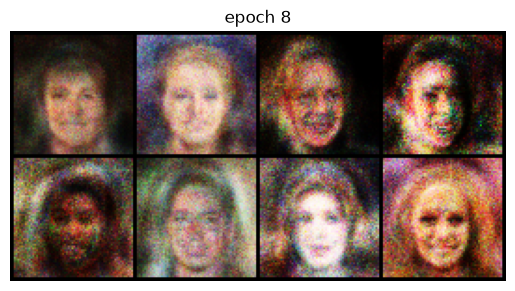

for epoch in 9/10... batch: 1... G-loss: 1.7823512554168701 & D-loss: 0.46375465393066406
for epoch in 9/10... batch: 51... G-loss: 1.7682225704193115 & D-loss: 0.4567395746707916
for epoch in 9/10... batch: 101... G-loss: 1.763542652130127 & D-loss: 0.49159032106399536
for epoch in 9/10... batch: 151... G-loss: 1.6812641620635986 & D-loss: 0.45311206579208374
for epoch in 9/10... batch: 201... G-loss: 1.7082629203796387 & D-loss: 0.4837627410888672
for epoch in 9/10... batch: 251... G-loss: 1.8616714477539062 & D-loss: 0.44306033849716187
for epoch in 9/10... batch: 301... G-loss: 1.7899110317230225 & D-loss: 0.5491256713867188
for epoch in 9/10... batch: 351... G-loss: 1.8568696975708008 & D-loss: 0.40121519565582275
for epoch in 9/10... batch: 401... G-loss: 1.6893543004989624 & D-loss: 0.5125525593757629
for epoch in 9/10... batch: 451... G-loss: 1.819966435432434 & D-loss: 0.4750802516937256
for epoch in 9/10... batch: 501... G-loss: 1.6689242124557495 & D-loss: 0.5344183444976807

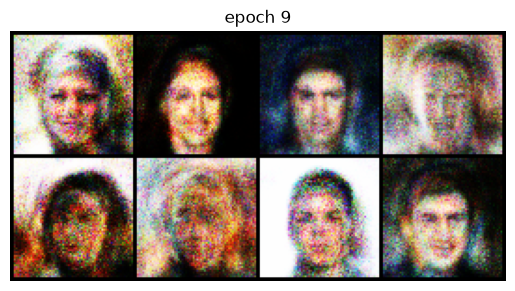

for epoch in 10/10... batch: 1... G-loss: 1.6432229280471802 & D-loss: 0.4119464159011841
for epoch in 10/10... batch: 51... G-loss: 1.7543307542800903 & D-loss: 0.5127331018447876
for epoch in 10/10... batch: 101... G-loss: 1.6165823936462402 & D-loss: 0.48889729380607605
for epoch in 10/10... batch: 151... G-loss: 1.5283030271530151 & D-loss: 0.467607706785202
for epoch in 10/10... batch: 201... G-loss: 1.6378759145736694 & D-loss: 0.45501741766929626
for epoch in 10/10... batch: 251... G-loss: 1.6606825590133667 & D-loss: 0.5650772452354431
for epoch in 10/10... batch: 301... G-loss: 1.8028911352157593 & D-loss: 0.42366722226142883
for epoch in 10/10... batch: 351... G-loss: 1.6787033081054688 & D-loss: 0.4738144278526306
for epoch in 10/10... batch: 401... G-loss: 1.7462681531906128 & D-loss: 0.4800984263420105
for epoch in 10/10... batch: 451... G-loss: 1.8052825927734375 & D-loss: 0.40218713879585266
for epoch in 10/10... batch: 501... G-loss: 1.6505409479141235 & D-loss: 0.54767

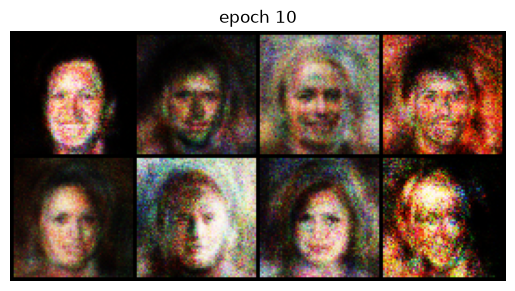

In [62]:
trian(generator, discriminator, dataloader, epochs = 10)